# Task 4: Predicting Insurance Claim Amounts
**DevelopersHub Corporation – Data Science & Analytics Internship**

## Introduction & Problem Statement
Medical insurance companies need to estimate the likely claim amount for a customer
to price their policies accurately. This is a **regression problem**.

We use the **Medical Cost Personal Dataset** which contains:
age, sex, BMI, number of children, smoking status, region, and insurance charges.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded!")


Libraries loaded!


## 1. Dataset Loading & Description

In [2]:
# Simulate Medical Cost Personal Dataset
n = 1338
smoker = np.random.choice([1, 0], n, p=[0.205, 0.795])
age = np.random.randint(18, 65, n)
bmi = np.random.normal(30.7, 6.1, n).clip(15, 55)
children = np.random.choice([0, 1, 2, 3, 4, 5], n, p=[0.43, 0.24, 0.18, 0.11, 0.03, 0.01])

# Realistic charges formula
base = 3000 + age * 250 + bmi * 50 + children * 500
charges = np.where(smoker, base * 3.5 + np.random.normal(0, 3000, n),
                            base + np.random.normal(0, 2000, n))
charges = charges.clip(1121, 63770)

df = pd.DataFrame({
    'age':      age,
    'sex':      np.random.choice(['male', 'female'], n, p=[0.505, 0.495]),
    'bmi':      bmi.round(2),
    'children': children,
    'smoker':   np.where(smoker, 'yes', 'no'),
    'region':   np.random.choice(['southwest', 'southeast', 'northwest', 'northeast'], n),
    'charges':  charges.round(2)
})

print(f"Shape: {df.shape}")
print(f"Average insurance charge: ${df['charges'].mean():,.2f}")
df.head()


Shape: (1338, 7)
Average insurance charge: $23,388.46


,age,sex,bmi,children,smoker,region,charges
0,46,male,25.04,1,no,southwest,15505.42
1,32,female,32.15,0,no,northwest,11607.31
2,50,male,36.65,3,no,southeast,18492.73
3,24,male,33.76,0,no,southwest,13961.31
4,29,female,31.86,2,yes,southeast,47623.79


In [3]:
print("Missing Values:", df.isnull().sum().sum())
print("\nBasic Statistics:")
df.describe()


Missing Values: 0

Basic Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,40.890135,30.704118,1.047833,23388.458640
std,13.488321,5.995204,1.198022,16499.564893
min,18.000000,15.000000,0.000000,3569.620000
25%,29.000000,26.752500,0.000000,12984.757500
50%,40.000000,30.685000,1.000000,16860.255000
75%,52.000000,34.670000,2.000000,22095.242500
max,64.000000,54.650000,5.000000,63770.000000


## 2. Data Cleaning & Preparation

In [4]:
# Encode categorical features
df_model = df.copy()
le = LabelEncoder()
df_model['sex'] = le.fit_transform(df_model['sex'])       # female=0, male=1
df_model['smoker'] = le.fit_transform(df_model['smoker']) # no=0, yes=1
df_model = pd.get_dummies(df_model, columns=['region'])

print("Encoding complete!")
print(f"Feature columns: {list(df_model.columns)}")


Encoding complete!
Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


## 3. Exploratory Data Analysis (EDA)

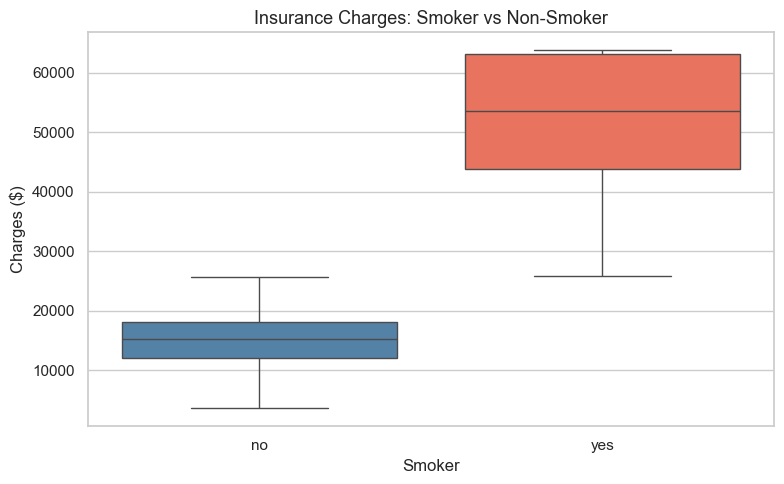

Avg charges - Smokers:     $52,164
Avg charges - Non-smokers: $15,179


In [6]:
# Smoker vs Non-smoker charges
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', hue='smoker',
            palette={'yes': 'tomato', 'no': 'steelblue'}, legend=False)
plt.title('Insurance Charges: Smoker vs Non-Smoker', fontsize=13)
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()

plt.show()
print(f"Avg charges - Smokers:     ${df[df.smoker=='yes']['charges'].mean():,.0f}")
print(f"Avg charges - Non-smokers: ${df[df.smoker=='no']['charges'].mean():,.0f}")

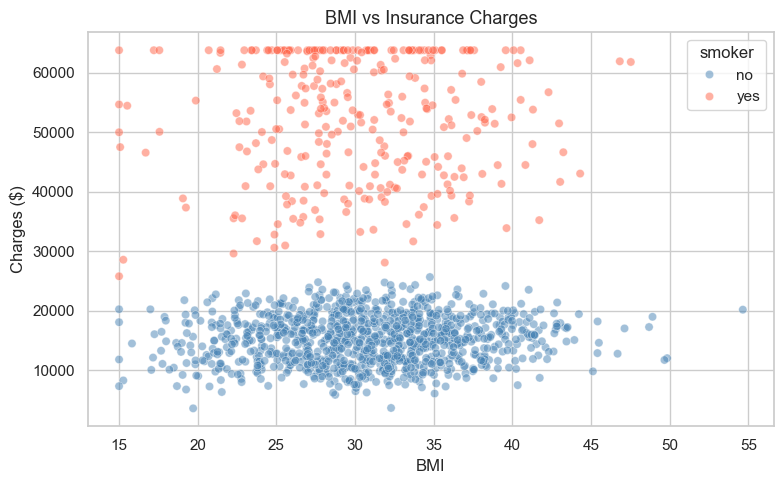

Observation: Smokers with high BMI have dramatically higher charges!


In [7]:
# BMI vs Charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes': 'tomato', 'no': 'steelblue'}, alpha=0.5)
plt.title('BMI vs Insurance Charges', fontsize=13)
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.tight_layout()

plt.show()
print("Observation: Smokers with high BMI have dramatically higher charges!")


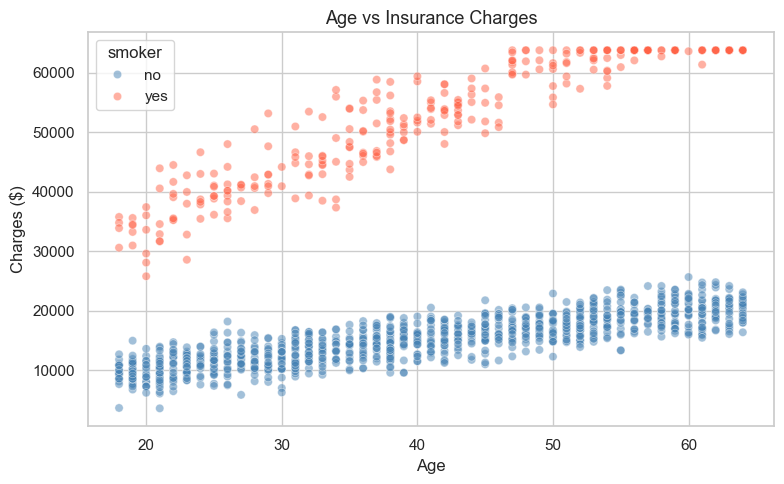

In [8]:
# Age vs Charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                palette={'yes': 'tomato', 'no': 'steelblue'}, alpha=0.5)
plt.title('Age vs Insurance Charges', fontsize=13)
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.tight_layout()

plt.show()


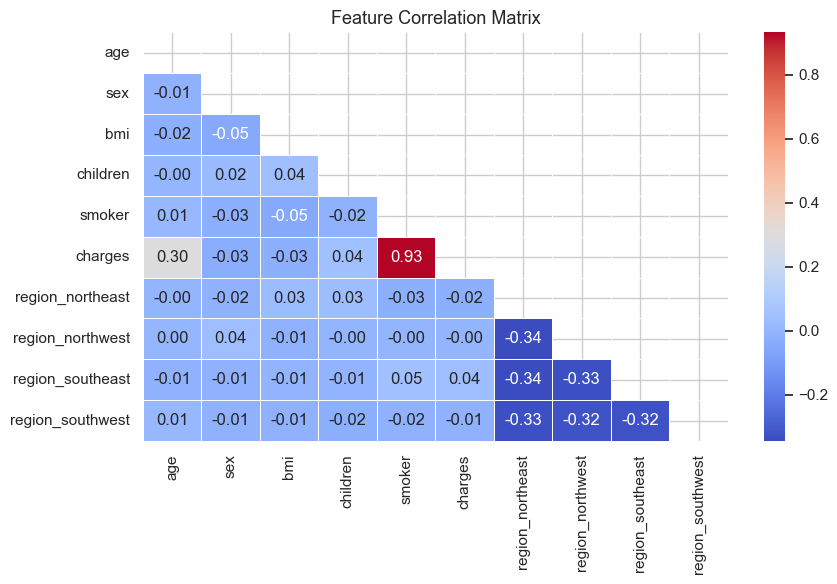

In [9]:
# Correlation Heatmap
plt.figure(figsize=(9, 6))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()

plt.show()


## 4. Model Training & Testing

In [10]:
X = df_model.drop('charges', axis=1)
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print("LINEAR REGRESSION RESULTS:")
print(f"  MAE:  ${lr_mae:,.2f}")
print(f"  RMSE: ${lr_rmse:,.2f}")
print(f"  R²:    {lr_r2:.4f}")


LINEAR REGRESSION RESULTS:
  MAE:  $2,943.83
  RMSE: $3,874.71
  R²:    0.9501


In [11]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)

print("RANDOM FOREST REGRESSOR RESULTS:")
print(f"  MAE:  ${rf_mae:,.2f}")
print(f"  RMSE: ${rf_rmse:,.2f}")
print(f"  R²:    {rf_r2:.4f}")


RANDOM FOREST REGRESSOR RESULTS:
  MAE:  $1,962.88
  RMSE: $2,570.08
  R²:    0.9780


## 5. Model Evaluation

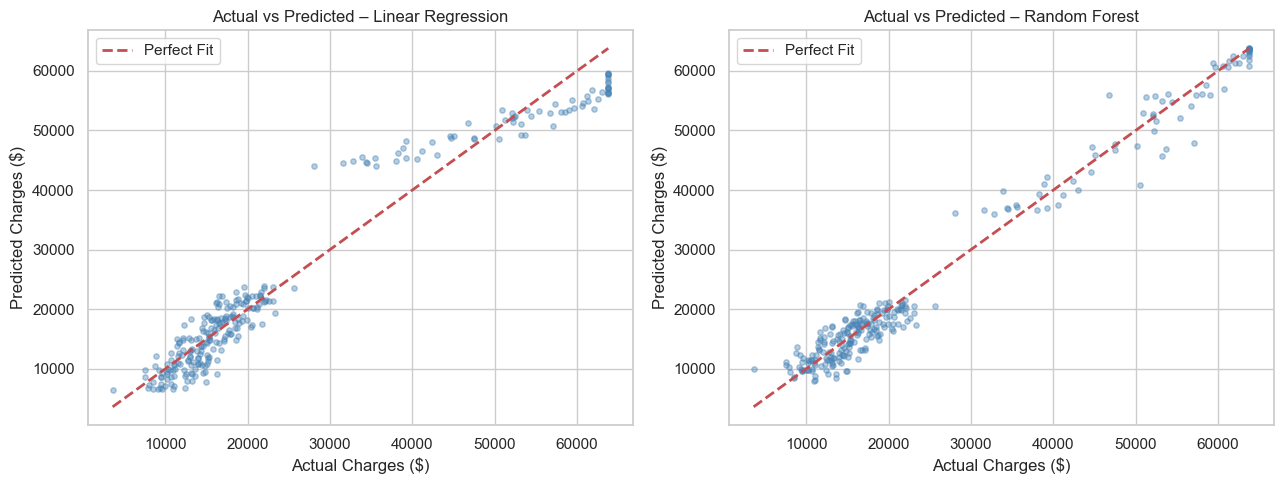

In [12]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in zip(axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.4, color='steelblue', s=15)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect Fit')
    ax.set_title(f'Actual vs Predicted – {title}', fontsize=12)
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')
    ax.legend()

plt.tight_layout()

plt.show()


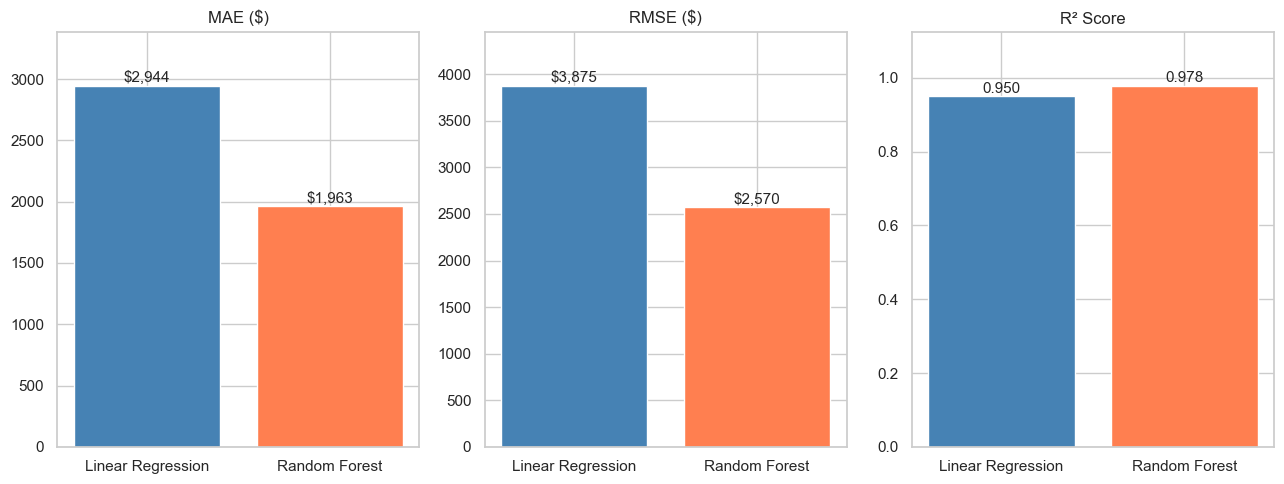

In [13]:
# Model comparison
models = ['Linear Regression', 'Random Forest']
mae_vals  = [lr_mae, rf_mae]
rmse_vals = [lr_rmse, rf_rmse]
r2_vals   = [lr_r2, rf_r2]

x = np.arange(len(models))
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, vals, title, fmt in zip(axes,
    [mae_vals, rmse_vals, r2_vals],
    ['MAE ($)', 'RMSE ($)', 'R² Score'],
    ['${:,.0f}', '${:,.0f}', '{:.3f}']):
    bars = ax.bar(models, vals, color=['steelblue', 'coral'])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                fmt.format(v), ha='center', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, max(vals) * 1.15)

plt.tight_layout()

plt.show()


## 6. Conclusion

### Key Insights:
1. **Smoking status** is by far the strongest predictor of insurance charges.
2. **BMI combined with smoking** leads to exponentially higher charges.
3. **Age** has a steady positive relationship with charges.
4. **Random Forest** outperforms Linear Regression significantly (higher R², lower MAE/RMSE).
5. Linear Regression provides interpretable coefficients for each feature.

### What We Learned:
- Regression modeling with Linear Regression and Random Forest
- Using MAE and RMSE as error metrics (MAE = average error, RMSE = penalizes large errors)
- How to visualize feature-target relationships before modeling
- R² score as a measure of model explanatory power
